# Memory dynamics

Visualize the non-Markovian memory coefficients of the projection-based effective process and compare their lag profiles across pseudo-label strengths.

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    trajectory_diagnostics,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler


The production recursion uses orthogonal-basis memory coordinates $\psi_t^{[w]}$ and $\psi_t^{[g]}$.  For interpretation, this notebook lazily reconstructs the diagnostic raw-trajectory coefficients $\phi_t^{[w]}$ and $\phi_t^{[g]}$; these agree with original-column coefficients when no nonzero direction was truncated.  They are not computed by autograd.

In [23]:
SEED = 7100
T, D, DELTA = 50, 2_000, 2.0
K_W, K_G = 5_500, 6_500
PIS = (0.0, 0.5, 5.0, 10.0)
runs = {}
for index, pi in enumerate(PIS):
    cfg = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=pi, kappa=logit(0.8))
    runs[pi] = run_experiment(
        name=rf"pi={pi}", d=D, delta=DELTA, n_test=1_000, label_prior=0.2, rho=0.1, sigma=1.0, signal_std=1.0,
        algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
    )

def memory_matrix(se, kind, *, absolute=True):
    matrix = np.full((T, T), np.nan)
    getter = se.compute_weight_memory if kind == "w" else se.compute_residual_memory
    for t in range(T):
        coefficients = as_numpy(getter(t))
        matrix[t, :coefficients.size] = np.abs(coefficients) if absolute else coefficients
    return matrix

def lag_profile(matrix):
    return np.array([np.nanmean(np.diag(matrix, k=-lag)) if np.diag(matrix, k=-lag).size else np.nan for lag in range(T)])

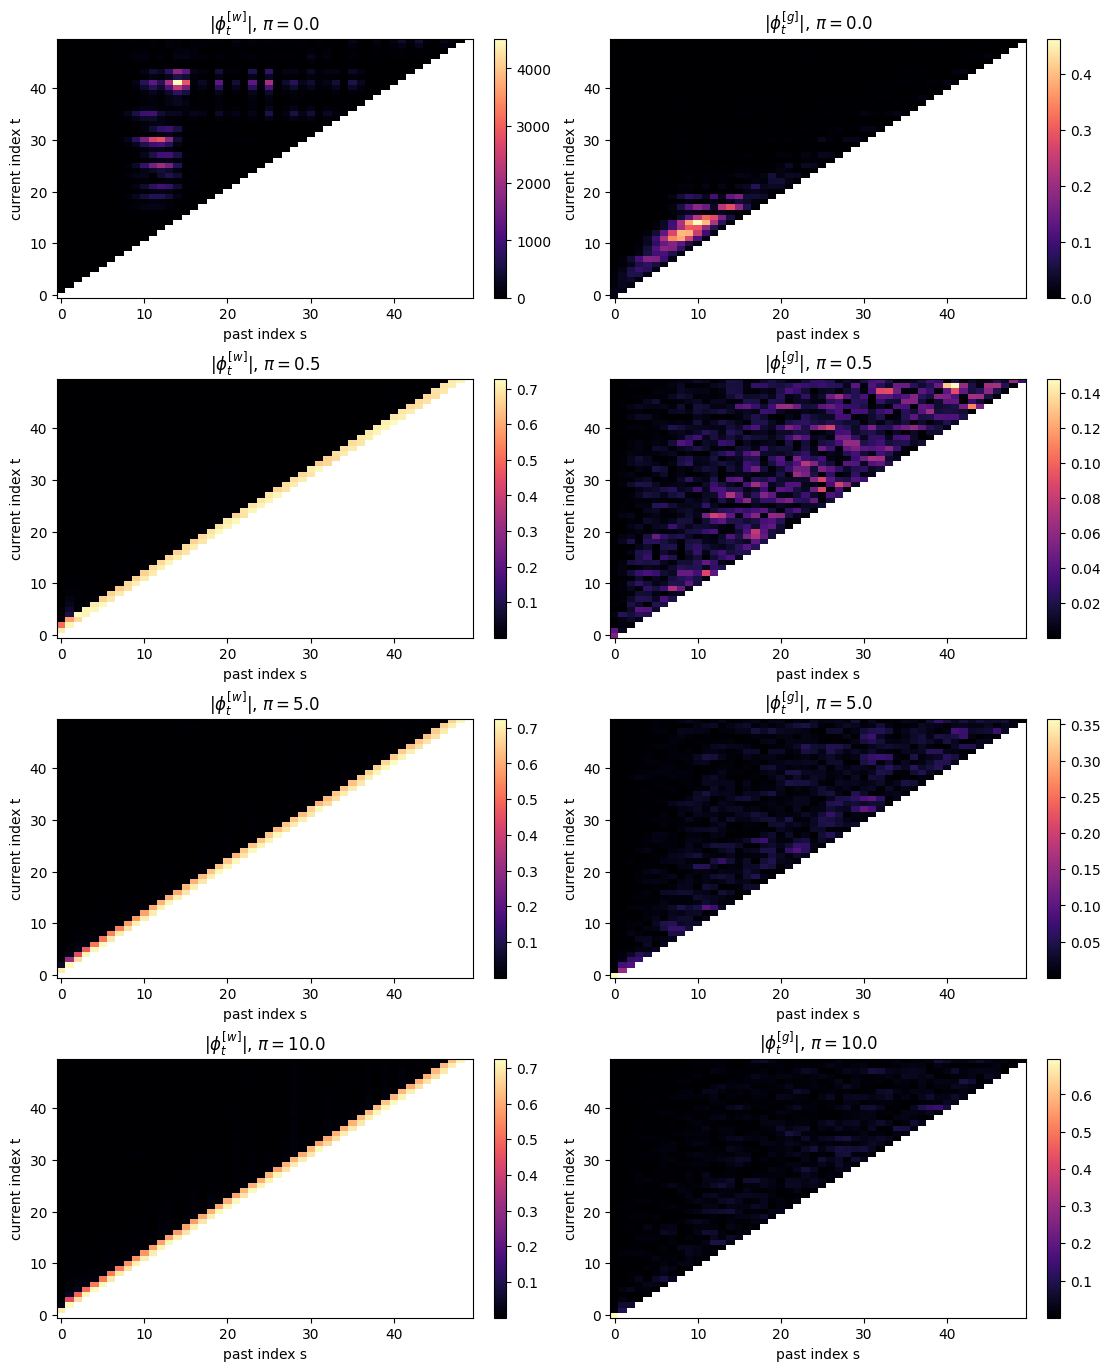

In [24]:
fig, axes = plt.subplots(len(PIS), 2, figsize=(11, 3.4 * len(PIS)), constrained_layout=True)
for row, pi in enumerate(PIS):
    se = runs[pi].se
    for column, kind in enumerate(("w", "g")):
        matrix = memory_matrix(se, kind)
        image = axes[row, column].imshow(matrix, origin="lower", aspect="auto", cmap="magma")
        axes[row, column].set(title=rf"$|\phi_t^{{[{kind}]}}|$, $\pi={pi}$", xlabel="past index s", ylabel="current index t")
        fig.colorbar(image, ax=axes[row, column])
plt.show()

/var/folders/1v/q141c9gj6fxf_hkyjl6w9y8c0000gn/T/ipykernel_62241/3147870770.py:22: RuntimeWarning: Mean of empty slice
  return np.array([np.nanmean(np.diag(matrix, k=-lag)) if np.diag(matrix, k=-lag).size else np.nan for lag in range(T)])


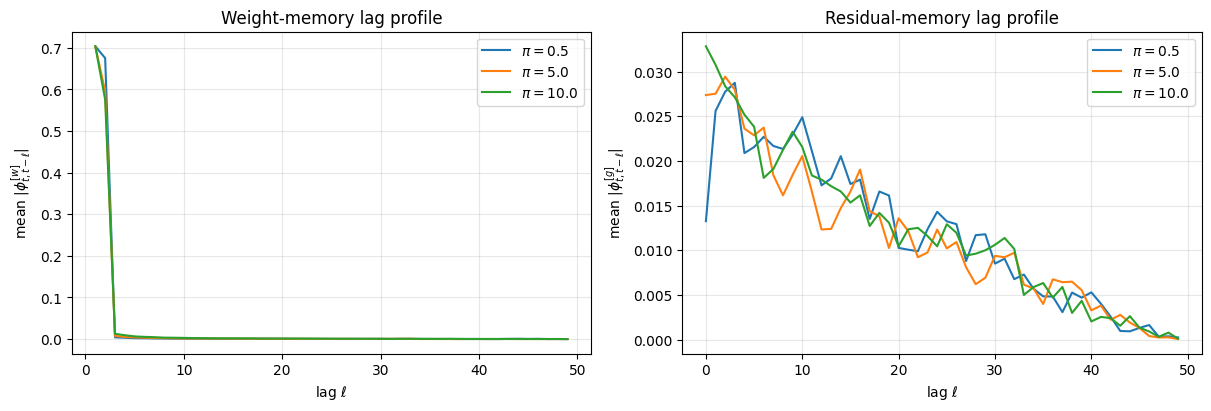

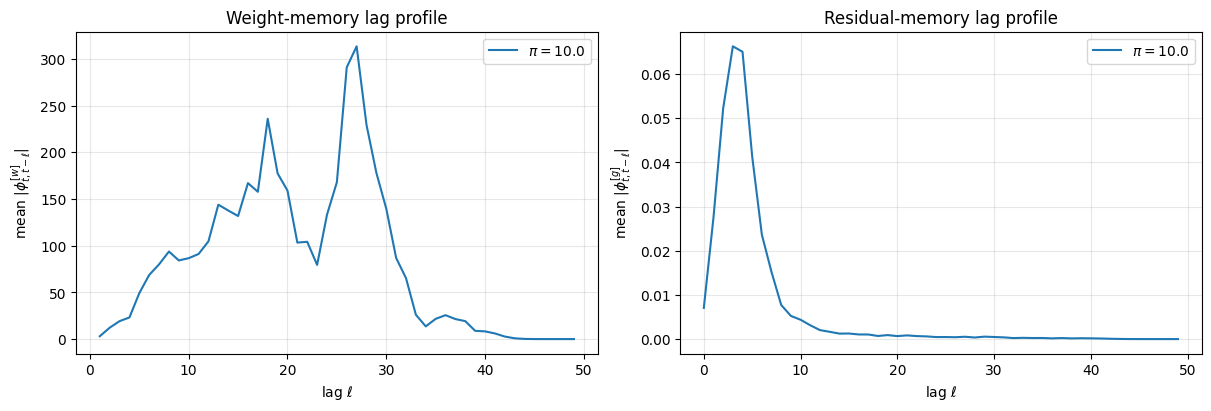

In [25]:
original_runs = runs.copy()
runs_pi_0 = runs.pop(0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for pi, run in runs.items():
    axes[0].plot(lag_profile(memory_matrix(run.se, "w")), label=rf"$\pi={pi}$")
    axes[1].plot(lag_profile(memory_matrix(run.se, "g")), label=rf"$\pi={pi}$")
axes[0].set(title=r"Weight-memory lag profile", xlabel=r"lag $\ell$", ylabel=r"mean $|\phi_{t,t-\ell}^{[w]}|$")
axes[1].set(title=r"Residual-memory lag profile", xlabel=r"lag $\ell$", ylabel=r"mean $|\phi_{t,t-\ell}^{[g]}|$")
for ax in axes: ax.grid(alpha=0.3); ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(lag_profile(memory_matrix(runs_pi_0.se, "w")), label=rf"$\pi={pi}$")
axes[1].plot(lag_profile(memory_matrix(runs_pi_0.se, "g")), label=rf"$\pi={pi}$")
axes[0].set(title=r"Weight-memory lag profile", xlabel=r"lag $\ell$", ylabel=r"mean $|\phi_{t,t-\ell}^{[w]}|$")
axes[1].set(title=r"Residual-memory lag profile", xlabel=r"lag $\ell$", ylabel=r"mean $|\phi_{t,t-\ell}^{[g]}|$")
for ax in axes: ax.grid(alpha=0.3); ax.legend()
plt.show()

## Signed, comparable memory profiles

The absolute-value maps are useful for memory magnitude, but conceal cancellation.  The following plot uses common color limits across pseudo-label weights and reports signed lag profiles alongside the supervised baseline.

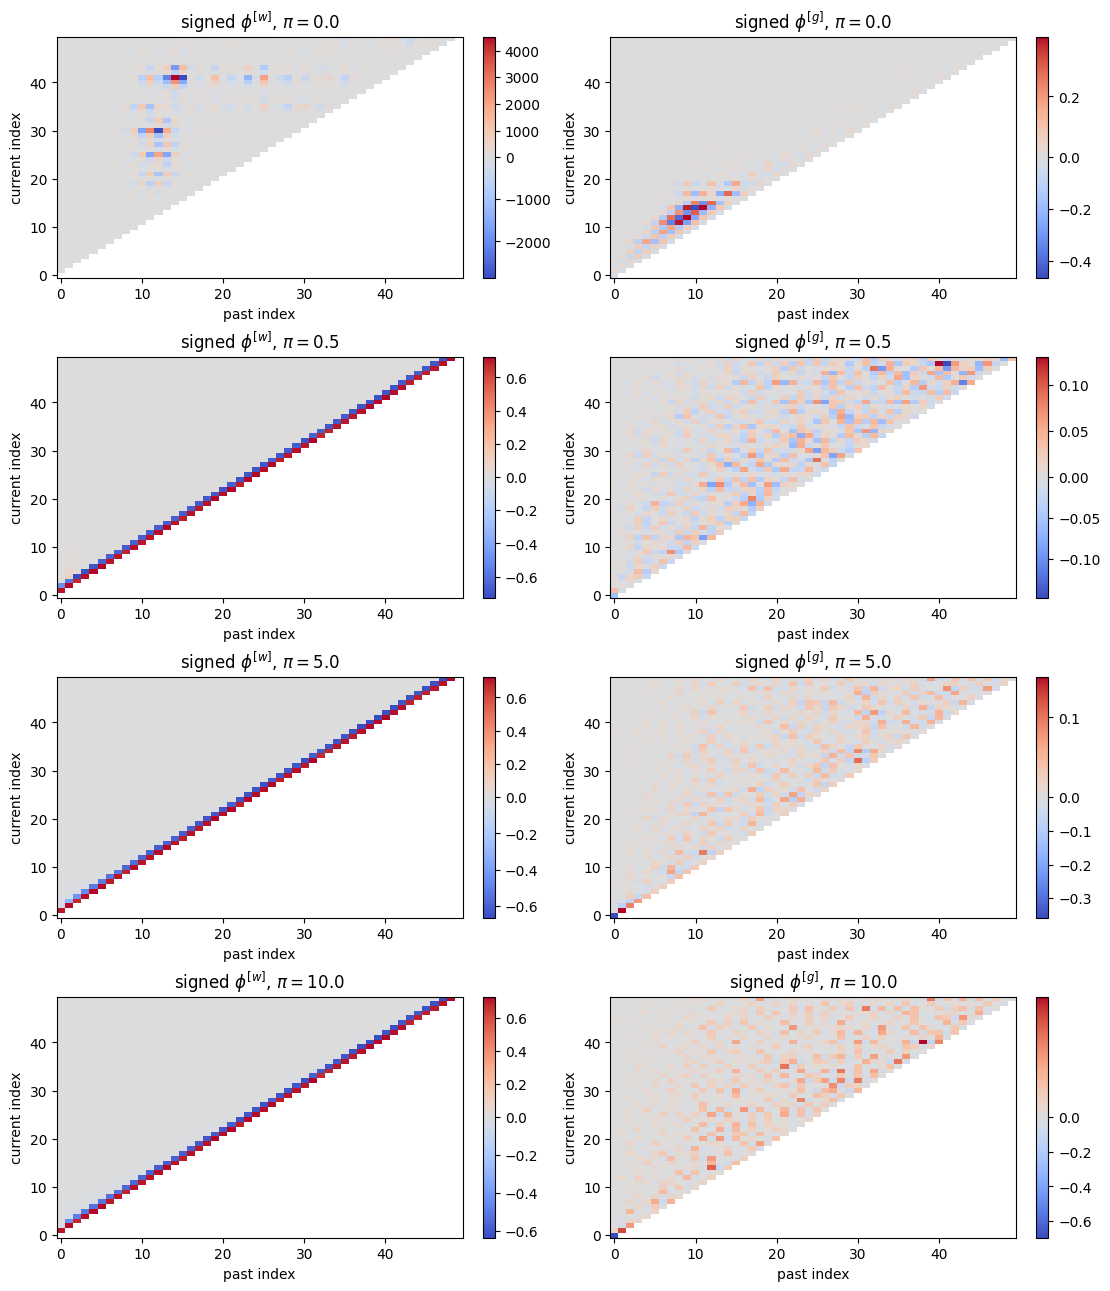

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(len(PIS), 2, figsize=(11, 3.2 * len(PIS)), constrained_layout=True)

for row, pi in enumerate(PIS):
    for column, kind in enumerate(("w", "g")):
        ax = axes[row, column]
        
        # Extract the specific data matrix for the current parameter regime
        data = memory_matrix(original_runs[pi].se, kind, absolute=False)
        
        # Compute local extrema
        val_min = np.nanmin(data)
        val_max = np.nanmax(data)
        
        # Enforce the strict inequality vmin < 0 < vmax required by TwoSlopeNorm
        val_min = min(val_min, -1e-8)
        val_max = max(val_max, 1e-8)
        
        # Instantiate the two-slope topological mapping centered at zero
        norm = TwoSlopeNorm(vcenter=0.0, vmin=val_min, vmax=val_max)
        
        # Plot using the local norm rather than a global scalar limit
        image = ax.imshow(
            data, 
            origin="lower", 
            aspect="auto", 
            cmap="coolwarm", 
            norm=norm
        )
        
        ax.set(
            title=rf"signed $\phi^{{[{kind}]}}$, $\pi={pi}$", 
            xlabel="past index", 
            ylabel="current index"
        )
        fig.colorbar(image, ax=ax)

plt.show()